In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv("AB_NYC_2019.csv")

In [5]:
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [6]:
df.shape

(48895, 16)

In [7]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [13]:
df_numeric = [feature for feature in df.columns if df[feature].dtype != 'O'] 
df_categorical = [feature for feature in df.columns if df[feature].dtype == 'O'] 

In [16]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [17]:
df_test = df.copy()

In [20]:
df_test["reviews_per_month"] = df_test["reviews_per_month"].fillna(0)

In [66]:
df_test["last_review"] = df_test["last_review"].fillna(0)

In [67]:
df_test.isnull().sum()

id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [63]:
df_test = df_test.drop(columns=["name", "host_name"])

In [68]:
df_test.isnull().sum()

id                                0
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [39]:
df_test["last_review"] = pd.to_datetime(df_test["last_review"])

In [58]:
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [61]:
df_test["host_name"] = df["host_name"]

In [69]:
df_test.head(5)

,id,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19 00:00:00,0.21,6,365
1,2595,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21 00:00:00,0.38,2,355
2,3647,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0,0.00,1,365
3,3831,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05 00:00:00,4.64,1,194
4,5022,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19 00:00:00,0.10,1,0


In [70]:
df_test.duplicated().sum()

np.int64(0)

In [71]:
df_test = df_test.drop(columns = ["id", "host_id"])

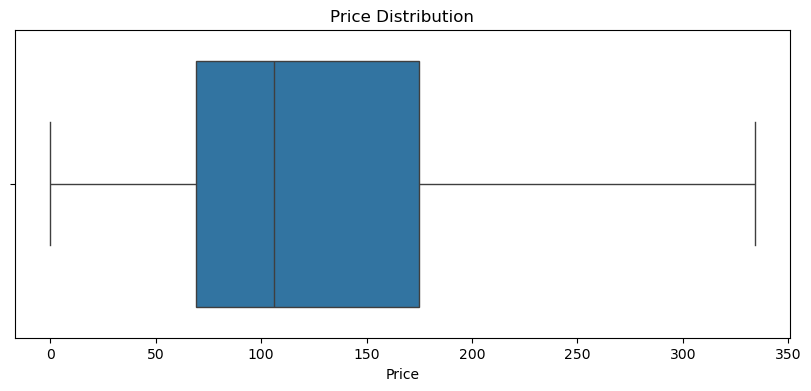

In [81]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_test["price"], showfliers=False)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

In [83]:
df_test[["price", "minimum_nights", "availability_365"]].describe()

,price,minimum_nights,availability_365
count,48895.000000,48895.000000,48895.000000
mean,152.720687,7.029962,112.781327
std,240.154170,20.510550,131.622289
min,0.000000,1.000000,0.000000
25%,69.000000,1.000000,0.000000
50%,106.000000,3.000000,45.000000
75%,175.000000,5.000000,227.000000
max,10000.000000,1250.000000,365.000000


In [89]:
df_test[df_test["price"] == 0].count()

neighbourhood_group               11
neighbourhood                     11
latitude                          11
longitude                         11
room_type                         11
price                             11
minimum_nights                    11
number_of_reviews                 11
last_review                       11
reviews_per_month                 11
calculated_host_listings_count    11
availability_365                  11
dtype: int64

In [91]:
df_test = df_test[df_test["price"] != 0]

In [92]:
df_test["price"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25     69.0
0.50    106.0
0.75    175.0
0.90    269.0
0.95    355.0
0.99    799.0
Name: price, dtype: float64

In [95]:
df_test["price"].sort_values(ascending=False).reset_index()

,index,price
0,29238,10000
1,17692,10000
2,9151,10000
3,12342,9999
4,40433,9999
...,...,...
48879,22835,10
48880,32810,10
48881,21700,10
48882,23256,10


In [96]:
upper_limit = df_test["price"].quantile(0.99)
df_test = df_test[df_test["price"] <= upper_limit]

In [97]:
df_test.shape

(48410, 12)

In [98]:
(df_test["price"] == 0).sum()

np.int64(0)

In [101]:
df_test["minimum_nights"].quantile([0.50, 0.75, 0.90, 0.95, 0.99])
df_test["minimum_nights"].max()

1250

In [102]:
df_test = df_test[df_test["minimum_nights"] <= 40]

In [103]:
df_test.shape

(47928, 12)

In [104]:
for col in ["neighbourhood_group", "neighbourhood", "room_type"]:
    print(col, df_test[col].nunique())

neighbourhood_group 5
neighbourhood 220
room_type 3


In [107]:
# one-hot encoding

# az veri var bu sebeple one hote mantıklı 2 kolon için. neighbourhood için ise price mean encoded

In [113]:
df_encoded = pd.get_dummies(
    df_test, 
    columns=["neighbourhood_group", "room_type"],
    drop_first=True
)

In [106]:
df_encoded

,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Bronx,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,Kensington,40.64749,-73.97237,149,1,9,2018-10-19 00:00:00,0.21,6,365,False,True,False,False,False,False,True,False
1,Midtown,40.75362,-73.98377,225,1,45,2019-05-21 00:00:00,0.38,2,355,False,False,True,False,False,True,False,False
2,Harlem,40.80902,-73.94190,150,3,0,0,0.00,1,365,False,False,True,False,False,False,True,False
3,Clinton Hill,40.68514,-73.95976,89,1,270,2019-07-05 00:00:00,4.64,1,194,False,True,False,False,False,True,False,False
4,East Harlem,40.79851,-73.94399,80,10,9,2018-11-19 00:00:00,0.10,1,0,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Bedford-Stuyvesant,40.67853,-73.94995,70,2,0,0,0.00,2,9,False,True,False,False,False,False,True,False
48891,Bushwick,40.70184,-73.93317,40,4,0,0,0.00,2,36,False,True,False,False,False,False,True,False
48892,Harlem,40.81475,-73.94867,115,10,0,0,0.00,1,27,False,False,True,False,False,True,False,False
48893,Hell's Kitchen,40.75751,-73.99112,55,1,0,0,0.00,6,2,False,False,True,False,False,False,False,True


In [111]:
df_test["neighbourhood_encoded"] = df_test.groupby("neighbourhood")["price"].transform("mean")

In [112]:
df_test.head(5)

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_encoded
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19 00:00:00,0.21,6,365,93.160920
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21 00:00:00,0.38,2,355,256.540431
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0,0.00,1,365,111.589381
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05 00:00:00,4.64,1,194,144.101604
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19 00:00:00,0.10,1,0,120.689937


In [115]:
df_test.head(3)

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_encoded
0,Brooklyn,40.64749,-73.97237,Private room,149,1,9,2018-10-19 00:00:00,0.21,6,365,93.160920
1,Manhattan,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21 00:00:00,0.38,2,355,256.540431
2,Manhattan,40.80902,-73.94190,Private room,150,3,0,0,0.00,1,365,111.589381


In [ ]:
""" 
Case 1 — Target değişkeni anlama

Önce price değişkenini tek başına incele.

Bakman gerekenler:

dağılım nasıl
sağa çarpık mı
ortalama ile median arasında ciddi fark var mı
hala outlier hissi var mı

Sorular:

fiyatlar çoğunlukla hangi aralıkta toplanıyor
pahalı evler az sayıda mı
model kurarken log transformation gerekir mi

"""

<Axes: xlabel='price', ylabel='Density'>

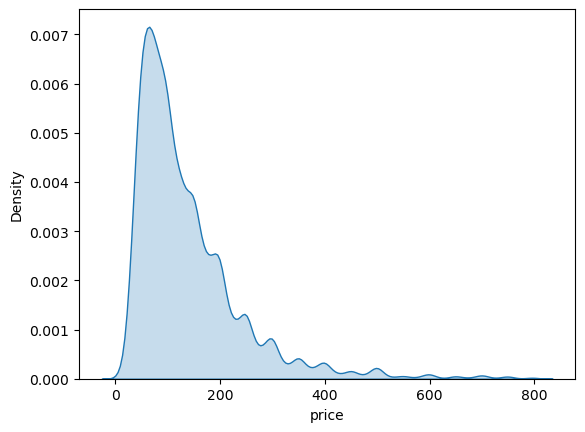

In [120]:
sns.kdeplot(x=df_test["price"], fill=True)

<Axes: xlabel='price'>

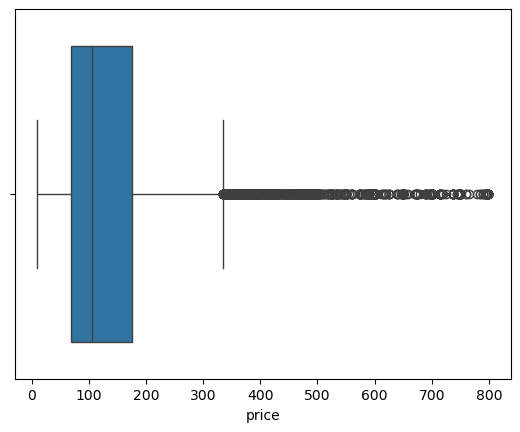

In [121]:
sns.boxplot(x=df_test["price"], fill=True)

In [122]:
df_test["price"].mean()

np.float64(137.65320898013687)

In [ ]:
""" 
Case 2 — Kategorik değişkenlerin target üzerindeki etkisi

Şu değişkenleri price ile birlikte düşün:

neighbourhood_group
room_type

Bakman gerekenler:

hangi grup daha pahalı
hangi grubun median fiyatı daha yüksek
hangi grupta dağılım daha geniş
varyans hangi kategoride daha fazla

Sorular:

Manhattan gerçekten en pahalı bölge mi
entire home/apartment en pahalı oda tipi mi
private room ve shared room arasında ciddi fark var mı

"""

In [128]:
df_test.groupby(["neighbourhood_group"])["price"].agg(["mean", "median", "max", "min", "sum", "std", "var", "count"])

,mean,median,max,min,sum,std,var,count
neighbourhood_group,,,,,,,,
Bronx,84.032558,65.0,680,10,90335,69.703294,4858.549218,1075
Brooklyn,115.980828,90.0,795,10,2298856,85.964950,7389.972589,19821
Manhattan,173.158898,149.0,799,10,3644129,116.711936,13621.675948,21045
Queens,94.224595,75.0,750,10,529448,69.306133,4803.340078,5619
Staten Island,94.225543,75.0,700,13,34675,75.792925,5744.567520,368


In [129]:
df_test.groupby(["room_type"])["price"].agg(["mean", "median", "max", "min", "sum", "std", "var", "count"])

,mean,median,max,min,sum,std,var,count
room_type,,,,,,,,
Entire home/apt,189.491925,160.0,799,10,4681777,109.865251,12070.373316,24707
Private room,83.439408,70.0,799,10,1842509,59.368508,3524.619692,22082
Shared room,64.229148,45.0,725,10,73157,60.634368,3676.526531,1139


In [ ]:
""" 
std: ortalamadan ne kadar uzaklaştığını gösterir. örneğin ortalama 70 std 5 ise sınıf not ort. için,
demek ki notlar 75-65 arasına sıkışmış demektir.
d"""

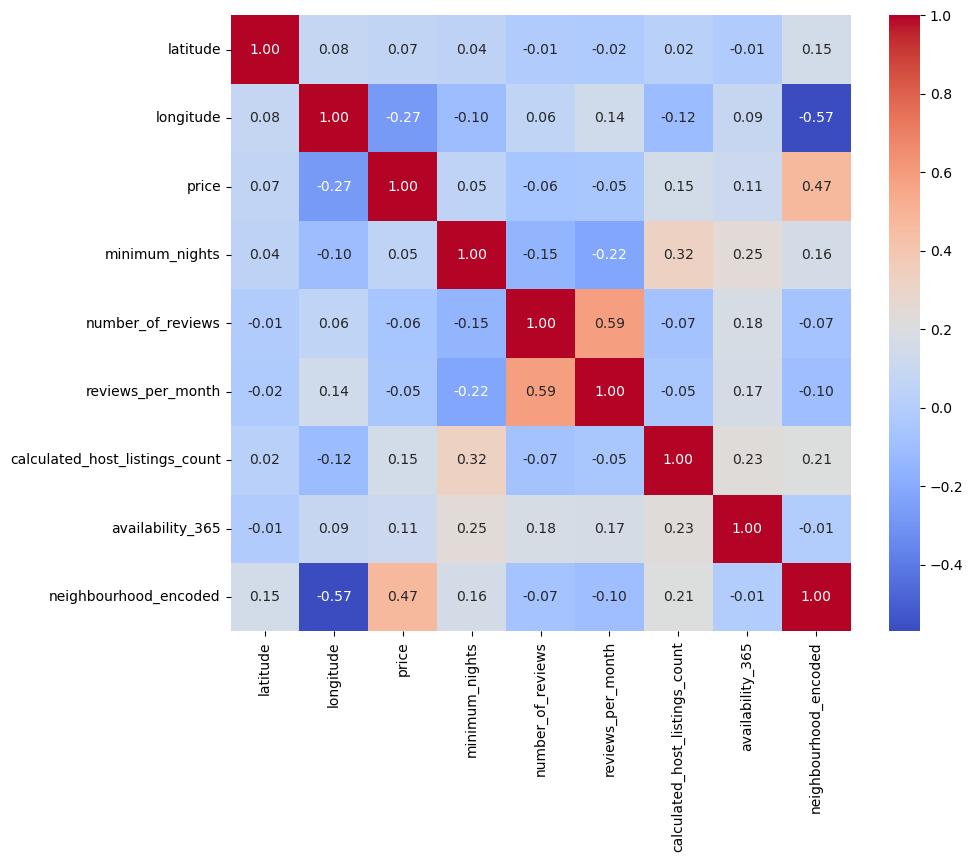

In [132]:
corr = df_test.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [135]:
numeric_columns = [feature for feature in df_test.columns if df_test[feature].dtype != 'O']

In [136]:
numeric_columns

['latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'neighbourhood_encoded']

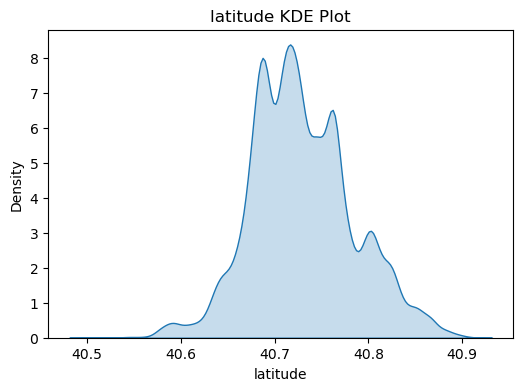

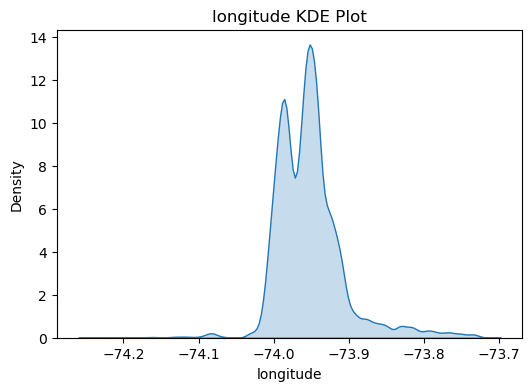

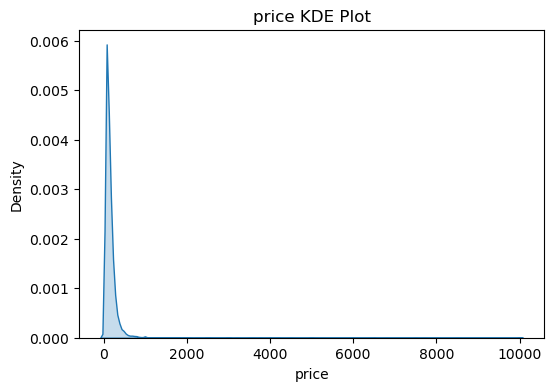

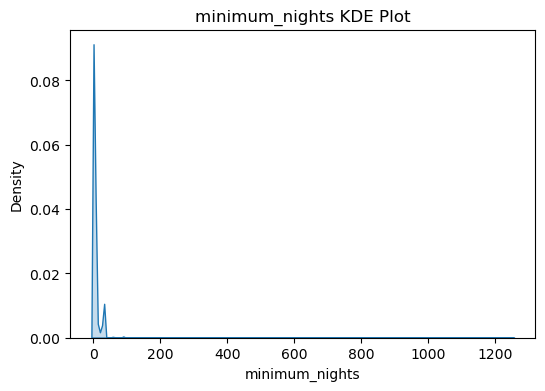

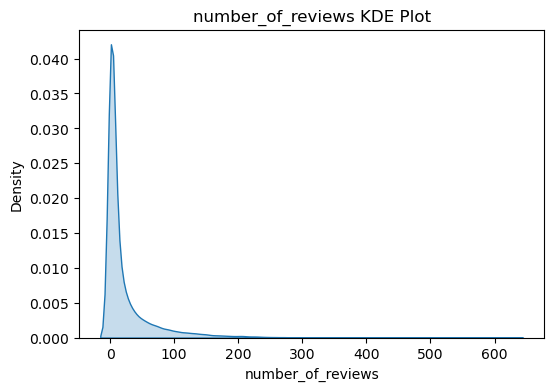

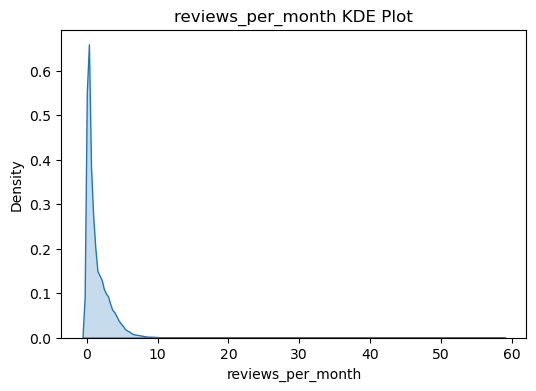

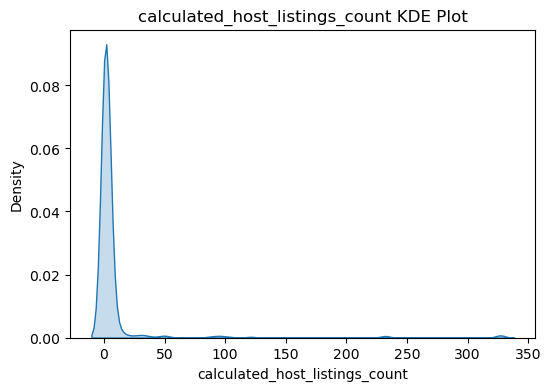

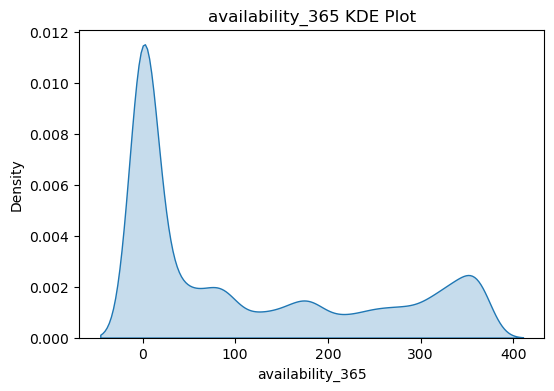

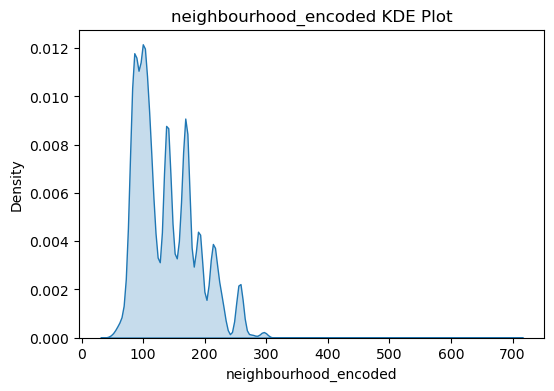

In [145]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(x=df[col], fill=True)
    plt.title(f"{col} KDE Plot")
    plt.xlabel(col)
    plt.show()

In [160]:
number_of_reviews_zero = df_test[df_test["number_of_reviews"] == 0]
number_of_reviews_not_zero = df_test[df_test["number_of_reviews"] != 0]

In [166]:
number_of_reviews_zero[["price"]].agg(["mean", "median", "count", "quantile"])

,price
mean,155.821767
median,120.000000
count,9611.000000
quantile,120.000000


In [164]:
number_of_reviews_not_zero[["price"]].agg(["mean", "median", "count", "quantile"])

,price
mean,133.096015
median,100.000000
count,38317.000000
quantile,100.000000


In [170]:
df_test[["number_of_reviews", "price"]].sort_values(by="number_of_reviews", ascending=False)

,number_of_reviews,price
11759,629,47
2031,607,49
2030,597,49
2015,594,49
13495,576,47
...,...,...
41266,0,125
17673,0,65
41268,0,40
41270,0,53


In [174]:
df_test.sort_values(by="number_of_reviews", ascending=False)

,neighbourhood_group,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_encoded
11759,Queens,40.66730,-73.76831,Private room,47,1,629,2019-07-05 00:00:00,14.58,2,333,91.839130
2031,Manhattan,40.82085,-73.94025,Private room,49,1,607,2019-06-21 00:00:00,7.75,3,293,111.589381
2030,Manhattan,40.82124,-73.93838,Private room,49,1,597,2019-06-23 00:00:00,7.72,3,342,111.589381
2015,Manhattan,40.82264,-73.94041,Private room,49,1,594,2019-06-15 00:00:00,7.57,3,339,111.589381
13495,Queens,40.66939,-73.76975,Private room,47,1,576,2019-06-27 00:00:00,13.40,2,173,91.839130
...,...,...,...,...,...,...,...,...,...,...,...,...
41266,Manhattan,40.76412,-73.98771,Private room,125,3,0,0,0.00,1,173,191.670833
17673,Brooklyn,40.68461,-73.95084,Private room,65,2,0,0,0.00,1,0,100.233243
41268,Bronx,40.85538,-73.91081,Shared room,40,1,0,0,0.00,1,0,69.571429
41270,Manhattan,40.80618,-73.94288,Private room,53,30,0,0,0.00,6,241,111.589381


In [177]:
df_test[["minimum_nights"]].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

,minimum_nights
0.25,1.0
0.50,2.0
0.75,5.0
0.90,20.0
0.95,30.0
0.99,30.0


In [180]:
df_test[["number_of_reviews"]].median()

number_of_reviews    5.0
dtype: float64

In [178]:
df_test[["number_of_reviews"]].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

,number_of_reviews
0.25,1.0
0.50,5.0
0.75,24.0
0.90,71.0
0.95,115.0
0.99,214.0


In [184]:
df_test.groupby("availability_365")[["price", "number_of_reviews"]].agg(["mean", "sum", "count"]).sort_values(by="availability_365", ascending=False)

price                 number_of_reviews               
                        mean      sum  count              mean     sum  count
availability_365                                                             
365               165.680034   194177   1172         10.791809   12648   1172
364               174.293478    80175    460          9.943478    4574    460
363               157.600877    35933    228         13.302632    3033    228
362               140.019608    21423    153         19.869281    3040    153
361               127.064220    13850    109         24.816514    2705    109
...                      ...      ...    ...               ...     ...    ...
4                 132.724138    30792    232         20.250000    4698    232
3                 136.644737    41540    304         25.526316    7760    304
2                 140.283019    37175    265         22.264151    5900    265
1                 130.111386    52565    404         25.539604   10318    404
0                 125.095522  2164778  17305          7.971916  137954  17305

[366 rows x 6 columns]

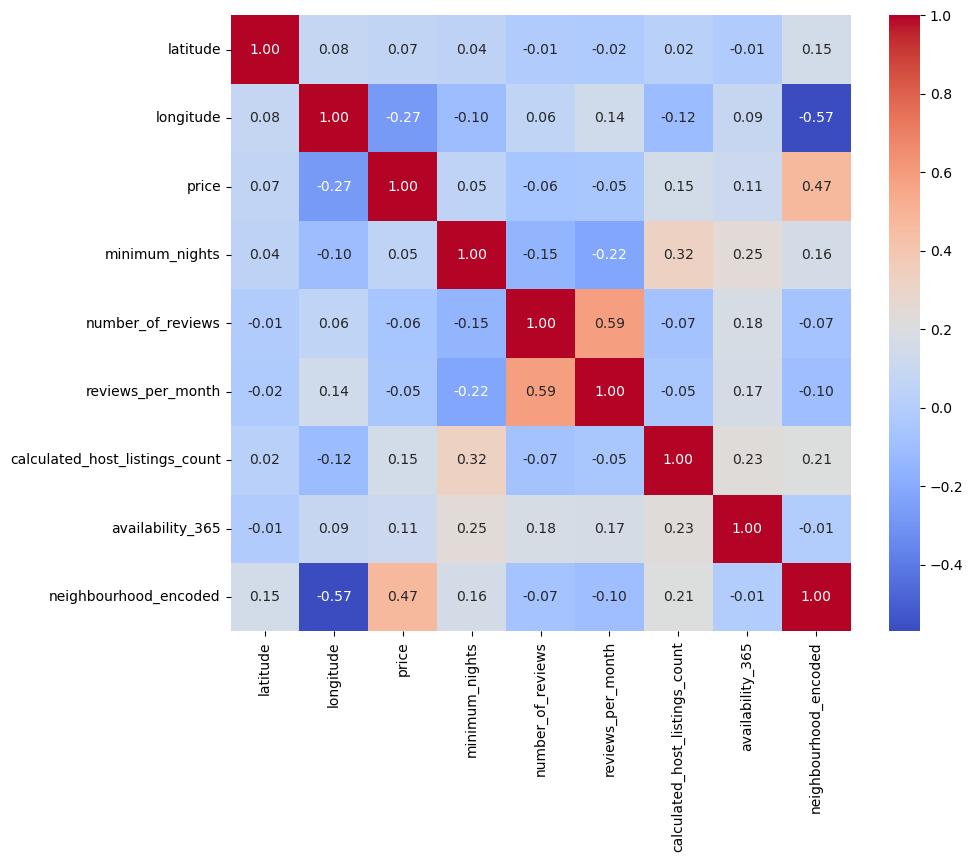

In [186]:
corr = df_test.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [187]:
y = df_test["price"]

X = df_test.drop(columns=["price", "neighbourhood_encoded", "last_review"])

In [189]:
X.head()

,neighbourhood_group,latitude,longitude,room_type,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,40.64749,-73.97237,Private room,1,9,0.21,6,365
1,Manhattan,40.75362,-73.98377,Entire home/apt,1,45,0.38,2,355
2,Manhattan,40.80902,-73.94190,Private room,3,0,0.00,1,365
3,Brooklyn,40.68514,-73.95976,Entire home/apt,1,270,4.64,1,194
4,Manhattan,40.79851,-73.94399,Entire home/apt,10,9,0.10,1,0


In [190]:
X.shape


(47928, 9)

In [192]:
y.head()

0    149
1    225
2    150
3     89
4     80
Name: price, dtype: int64

In [193]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [194]:
X_train.shape
X_test.shape
y_train.shape
y_test.shape

(9586,)

In [195]:
X_train.shape


(38342, 9)

In [196]:
X_test.shape

(9586, 9)

In [197]:
y_train.shape


(38342,)

In [198]:
y_test.shape

(9586,)

In [203]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38342 entries, 14778 to 16165
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   neighbourhood_group             38342 non-null  object 
 1   latitude                        38342 non-null  float64
 2   longitude                       38342 non-null  float64
 3   room_type                       38342 non-null  object 
 4   minimum_nights                  38342 non-null  int64  
 5   number_of_reviews               38342 non-null  int64  
 6   reviews_per_month               38342 non-null  float64
 7   calculated_host_listings_count  38342 non-null  int64  
 8   availability_365                38342 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 2.9+ MB


In [204]:
X = pd.get_dummies(X, columns=["neighbourhood_group", "room_type"], drop_first=True)

In [205]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [206]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38342 entries, 14778 to 16165
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   latitude                           38342 non-null  float64
 1   longitude                          38342 non-null  float64
 2   minimum_nights                     38342 non-null  int64  
 3   number_of_reviews                  38342 non-null  int64  
 4   reviews_per_month                  38342 non-null  float64
 5   calculated_host_listings_count     38342 non-null  int64  
 6   availability_365                   38342 non-null  int64  
 7   neighbourhood_group_Brooklyn       38342 non-null  bool   
 8   neighbourhood_group_Manhattan      38342 non-null  bool   
 9   neighbourhood_group_Queens         38342 non-null  bool   
 10  neighbourhood_group_Staten Island  38342 non-null  bool   
 11  room_type_Private room             38342 non-null  bool

In [207]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [208]:
y_pred = model.predict(X_test)

In [209]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print("RMSE:", rmse)

RMSE: 82.38438082241838


In [210]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [211]:
from sklearn.metrics import mean_squared_error

rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print("RF RMSE:", rmse_rf)

RF RMSE: 73.52409033935488


In [212]:
import pandas as pd

feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importances.head(10)

,feature,importance
11,room_type_Private room,0.232788
1,longitude,0.217047
0,latitude,0.175393
6,availability_365,0.107531
4,reviews_per_month,0.069976
2,minimum_nights,0.063579
3,number_of_reviews,0.059524
5,calculated_host_listings_count,0.042956
12,room_type_Shared room,0.027187
7,neighbourhood_group_Brooklyn,0.001504


In [214]:
import numpy as np

y_log = np.log1p(df_test["price"])

In [215]:
X = df_test.drop(columns=["price", "neighbourhood_encoded", "last_review"])
y = y_log

In [216]:
from sklearn.model_selection import train_test_split

X = pd.get_dummies(X, columns=["neighbourhood_group", "room_type"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [217]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_log = rf_model.predict(X_test)

In [218]:
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

In [219]:
from sklearn.metrics import mean_squared_error

rmse_log = mean_squared_error(y_true, y_pred) ** 0.5
print("Log RMSE:", rmse_log)

Log RMSE: 73.10849539385752


In [220]:
def host_segment(x):
    if x == 1:
        return "individual"
    elif x <= 5:
        return "small_multi"
    else:
        return "professional"

df_test["host_type"] = df_test["calculated_host_listings_count"].apply(host_segment)
df_test["host_type"].value_counts()

host_type
individual      31623
small_multi     11628
professional     4677
Name: count, dtype: int64

In [221]:
def host_segment(x):
    if x == 1:
        return "individual"
    elif x <= 5:
        return "small_multi"
    else:
        return "professional"

df_test["host_type"] = df_test["calculated_host_listings_count"].apply(host_segment)
df_test["host_type"].value_counts()

host_type
individual      31623
small_multi     11628
professional     4677
Name: count, dtype: int64

In [226]:
def availability_segment(x):
    if x <= 50:
        return "low_availability"
    elif x <= 200:
        return "medium_availability"
    else:
        return "high_availability"

df_test["availability_segment"] = df_test["availability_365"].apply(availability_segment)
df_test["availability_segment"].value_counts()

availability_segment
low_availability       24627
high_availability      12896
medium_availability    10405
Name: count, dtype: int64

In [222]:
def stay_segment(x):
    if x <= 3:
        return "short_stay"
    elif x <= 7:
        return "medium_stay"
    else:
        return "long_stay"

df_test["stay_type"] = df_test["minimum_nights"].apply(stay_segment)
df_test["stay_type"].value_counts()

stay_type
short_stay     32092
medium_stay     9075
long_stay       6761
Name: count, dtype: int64

In [223]:
df_test["demand_score"] = df_test["number_of_reviews"] * df_test["reviews_per_month"]
df_test[["number_of_reviews", "reviews_per_month", "demand_score"]].head()

,number_of_reviews,reviews_per_month,demand_score
0,9,0.21,1.89
1,45,0.38,17.10
2,0,0.00,0.00
3,270,4.64,1252.80
4,9,0.10,0.90


In [224]:
import numpy as np

y = np.log1p(df_test["price"])

X = df_test.drop(columns=["price", "neighbourhood_encoded", "last_review"])

In [228]:
# host_type
def host_segment(x):
    if x == 1:
        return "individual"
    elif x <= 5:
        return "small_multi"
    else:
        return "professional"

df_test["host_type"] = df_test["calculated_host_listings_count"].apply(host_segment)


# availability_segment
def availability_segment(x):
    if x <= 50:
        return "low_availability"
    elif x <= 200:
        return "medium_availability"
    else:
        return "high_availability"

df_test["availability_segment"] = df_test["availability_365"].apply(availability_segment)


# stay_type
def stay_segment(x):
    if x <= 3:
        return "short_stay"
    elif x <= 7:
        return "medium_stay"
    else:
        return "long_stay"

df_test["stay_type"] = df_test["minimum_nights"].apply(stay_segment)


# demand_score
df_test["demand_score"] = df_test["number_of_reviews"] * df_test["reviews_per_month"]

In [229]:
import numpy as np

y = np.log1p(df_test["price"])

X = df_test.drop(columns=["price", "neighbourhood_encoded", "last_review"])

In [231]:
rf_model.fit(X_train, y_train)

y_pred_log = rf_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

rmse_new = mean_squared_error(y_true, y_pred) ** 0.5
print("New RMSE:", rmse_new)

New RMSE: 73.10849539385752


In [233]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

y_pred_log = xgb_model.predict(X_test)

import numpy as np
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

from sklearn.metrics import mean_squared_error
rmse_xgb = mean_squared_error(y_true, y_pred) ** 0.5

print("XGB RMSE:", rmse_xgb)

XGB RMSE: 73.15503194925624
